In [ ]:
# Setup & Install dependencies

# "timm>=1.0.11"

!pip -q install kagglehub scikit-learn seaborn \
                grad-cam ptflops statsmodels scipy --upgrade

print("Installs complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 46.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 14.7 MB/s eta 0:00:00
Installs complete.


In [ ]:
!pip install -U \
torch \
torchvision \
timm \
pillow==11.0.0 \
rembg \
onnxruntime

  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of rembg to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of rembg to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.0 MB/s eta 0:00:00
   ━━━

In [ ]:
# Imports, config, reproducibility

import os, time, shutil, random, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import timm
import torchvision.models as tvmodels
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from rembg import remove
import io

In [ ]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 12
LR = 3e-4
PATIENCE = 4
NUM_WORKERS = 2
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
SPLIT_ROOT = "/content/data_split"
WEIGHTS_DIR = "/content/weights"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

RESULTS = {}

In [ ]:
print("Device:", DEVICE, "| LR:", LR, type(LR).__name__)
if DEVICE == "cpu": print("WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU.")

Device: cuda | LR: 0.0003 float


In [ ]:
# Download dataset and auto-locate the class folders

import kagglehub

download_path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
EXPECTED = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

def find_dataset_root(base):
    best, best_score = None, -1
    for dirpath, dirnames, _ in os.walk(base):
        subs = []
        for d in dirnames:
            if d.startswith("."): continue
            p = os.path.join(dirpath, d)
            try:
                if any(f.lower().endswith(IMG_EXT) for f in os.listdir(p)): subs.append(d.lower())
            except (NotADirectoryError, PermissionError): pass
        if not subs: continue
        score = len(set(subs) & EXPECTED) * 100 + len(subs)
        if score > best_score: best, best_score = dirpath, score
    if best is None: raise RuntimeError(f"No class folders under {base}")
    return best

Using Colab cache for faster access to the 'garbage-classification' dataset.


In [ ]:
DATA_ROOT = find_dataset_root(download_path)
CLASSES = sorted([d for d in os.listdir(DATA_ROOT)
                  if os.path.isdir(os.path.join(DATA_ROOT, d))
                  and any(f.lower().endswith(IMG_EXT) for f in os.listdir(os.path.join(DATA_ROOT, d)))])

NUM_CLASSES = len(CLASSES)

print("Image root:", DATA_ROOT)
print("Classes:", CLASSES)

Image root: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# class distribution

counts = {c: len([f for f in os.listdir(os.path.join(DATA_ROOT, c)) if f.lower().endswith(IMG_EXT)])
          for c in CLASSES}
print("Total:", sum(counts.values()))

Total: 2527


In [ ]:
for c, n in counts.items(): print(f"  {c:12s} {n}")

  cardboard    403
  glass        501
  metal        410
  paper        594
  plastic      482
  trash        137


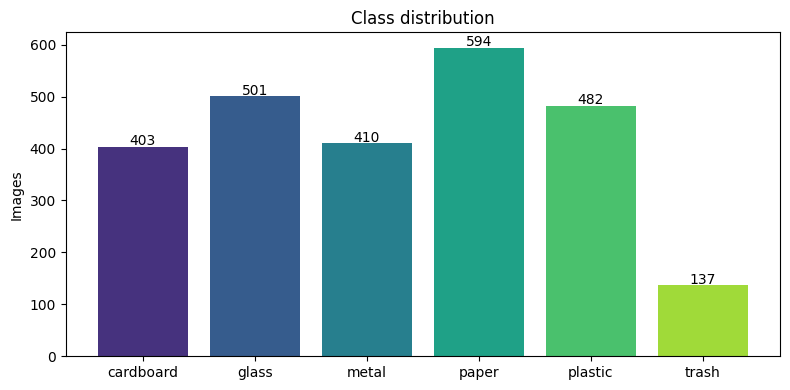

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=sns.color_palette("viridis", NUM_CLASSES))
plt.title("Class distribution"); plt.ylabel("Images")
for i, v in enumerate(counts.values()): plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout(); plt.show()

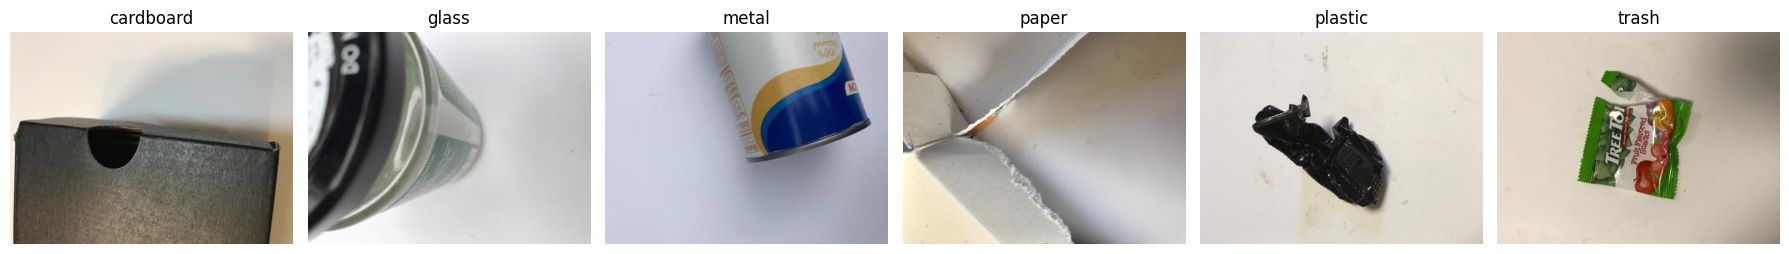

In [ ]:
# Display sample images (one per class)

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3))

for ax, c in zip(np.ravel(axes), CLASSES):
    d = os.path.join(DATA_ROOT, c)
    f = next(f for f in os.listdir(d) if f.lower().endswith(IMG_EXT))
    ax.imshow(Image.open(os.path.join(d, f)).convert("RGB")); ax.set_title(c); ax.axis("off")

plt.tight_layout(); plt.show()

In [ ]:
# Analyze image dimensions (sample up to 400 images for speed)

ws, hs = [], []
allp = [os.path.join(DATA_ROOT, c, f) for c in CLASSES
        for f in os.listdir(os.path.join(DATA_ROOT, c)) if f.lower().endswith(IMG_EXT)]
for p in random.sample(allp, min(400, len(allp))):
    try:
        with Image.open(p) as im: w, h = im.size; ws.append(w); hs.append(h)
    except Exception: pass

print(f"Width  min/med/max: {min(ws)}/{int(np.median(ws))}/{max(ws)}")
print(f"Height min/med/max: {min(hs)}/{int(np.median(hs))}/{max(hs)}")

Width  min/med/max: 512/512/512
Height min/med/max: 384/384/384


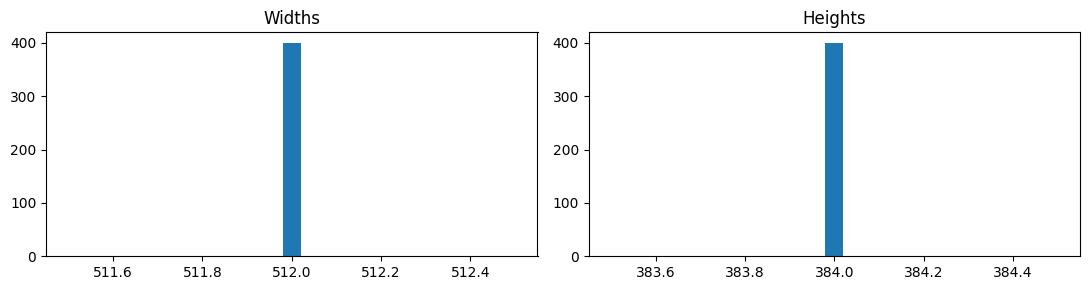

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(ws, bins=25); ax[0].set_title("Widths")
ax[1].hist(hs, bins=25); ax[1].set_title("Heights")
plt.tight_layout(); plt.show()

In [ ]:
# Stratified 70/15/15 split copied into train/val/test folders

def build_split(seed=SEED):
    if os.path.exists(SPLIT_ROOT): shutil.rmtree(SPLIT_ROOT)
    paths, labels = [], []
    for c in CLASSES:
        d = os.path.join(DATA_ROOT, c)
        for f in os.listdir(d):
            if f.lower().endswith(IMG_EXT): paths.append(os.path.join(d, f)); labels.append(c)
    p_tr, p_tmp, y_tr, y_tmp = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=seed)
    p_va, p_te, y_va, y_te = train_test_split(p_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)
    for split, (ps, ys) in {"train": (p_tr, y_tr), "val": (p_va, y_va), "test": (p_te, y_te)}.items():
        for c in CLASSES: os.makedirs(os.path.join(SPLIT_ROOT, split, c), exist_ok=True)
        for src, c in zip(ps, ys):
            shutil.copy(src, os.path.join(SPLIT_ROOT, split, c, os.path.basename(src)))
    print("train/val/test:", len(p_tr), len(p_va), len(p_te))

In [ ]:
build_split()

train/val/test: 1768 379 380


In [ ]:
# Augmentation + dataloaders + class weights (processed-data pipeline)

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_ds = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(SPLIT_ROOT, "test"),  transform=eval_tf)

assert train_ds.classes == CLASSES

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

cnt = np.bincount([y for _, y in train_ds.samples], minlength=NUM_CLASSES).astype(float)

class_weights = torch.tensor(cnt.sum() / (NUM_CLASSES * cnt), dtype=torch.float32)

TEST_TRUE = np.array([y for _, y in test_ds.samples])

print("Class weights:", np.round(class_weights.numpy(), 2))

Class weights: [1.04 0.84 1.03 0.71 0.87 3.07]


In [ ]:
# Model factory + shared train / evaluate / efficiency machinery

MODEL_REGISTRY = {
    "MobileNetV3-Large":  {"source": "timm", "names": ["mobilenetv3_large_100"]},
    "EfficientNet-Lite0": {"source": "timm", "names": ["tf_efficientnet_lite0", "efficientnet_lite0"]},
    "ShuffleNetV2":       {"source": "torchvision", "names": ["shufflenet_v2_x1_0"]},
    "GhostNet":           {"source": "timm", "names": ["ghostnet_100"]},
    "SqueezeNet":         {"source": "torchvision", "names": ["squeezenet1_1"]},
    "EfficientViT":       {"source": "timm", "names": ["efficientvit_b0", "efficientvit_b1",
                                                        "efficientvit_m1", "efficientvit_m0"]},
}

def build_model(spec, num_classes):
    if spec["source"] == "timm":
        err = None
        for n in spec["names"]:
            for pre in (True, False):
                try:
                    m = timm.create_model(n, pretrained=pre, num_classes=num_classes)
                    if not pre: print(f"  [warn] {n}: no pretrained weights, from scratch")
                    return m, n
                except Exception as e: err = e
        raise RuntimeError(f"Could not build {spec['names']}: {err}")
    n = spec["names"][0]
    if n == "shufflenet_v2_x1_0":
        m = tvmodels.shufflenet_v2_x1_0(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif n == "squeezenet1_1":
        m = tvmodels.squeezenet1_1(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Conv2d(512, num_classes, 1); m.num_classes = num_classes
    return m, n

def _infer(model, loader):
    model.eval(); ys, ps, prob = [], [], []
    with torch.inference_mode():
        for x, y in loader:
            out = model(x.to(DEVICE)); sm = F.softmax(out, 1).cpu().numpy()
            ps.extend(out.argmax(1).cpu().numpy()); ys.extend(y.numpy()); prob.append(sm)
    return np.array(ys), np.array(ps), np.concatenate(prob)

def train_model(model, name=""):
    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    best_f1, best_state, wait, hist = -1, None, 0, []
    for ep in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, val_loader)
        vf1 = f1_score(yv, pv, average="macro"); hist.append(vf1)
        print(f"    epoch {ep+1:02d}/{EPOCHS}  val_f1={vf1:.4f}")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE: print(f"    early stop @ {ep+1}"); break
    if best_state: model.load_state_dict(best_state)
    return model, hist

def evaluate_full(model, loader):
    y, p, prob = _infer(model, loader)
    yb = label_binarize(y, classes=list(range(NUM_CLASSES)))
    try: a = roc_auc_score(yb, prob, average="macro", multi_class="ovr")
    except Exception: a = float("nan")
    return {"accuracy": accuracy_score(y, p),
            "precision": precision_score(y, p, average="macro", zero_division=0),
            "recall": recall_score(y, p, average="macro", zero_division=0),
            "f1": f1_score(y, p, average="macro"), "roc_auc": a}, prob, p

def measure_efficiency(model):
    model = model.to("cpu").eval()
    tmp = "_s.pt"; torch.save(model.state_dict(), tmp)
    size_mb = os.path.getsize(tmp) / 1e6; os.remove(tmp)
    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    try:
        from ptflops import get_model_complexity_info
        macs, _ = get_model_complexity_info(model, (3, IMG_SIZE, IMG_SIZE),
                                            as_strings=False, print_per_layer_stat=False, verbose=False)
        gflops = round(macs * 2 / 1e9, 3)
    except Exception as e:
        gflops = float("nan"); print("  [warn] FLOPs failed:", e)
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    with torch.inference_mode():
        for _ in range(10): model(x)
        t = []
        for _ in range(100): s = time.perf_counter(); model(x); t.append((time.perf_counter() - s) * 1000)
    gpu_mb = float("nan")
    if DEVICE == "cuda":
        m = model.to("cuda"); torch.cuda.reset_peak_memory_stats()
        with torch.inference_mode(): m(torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device="cuda"))
        gpu_mb = round(torch.cuda.max_memory_allocated() / 1e6, 1); model.to("cpu")
    return {"params_M": round(params_m, 3), "gflops": gflops, "size_MB": round(size_mb, 2),
            "cpu_ms": round(float(np.mean(t)), 2), "cpu_ms_p95": round(float(np.percentile(t, 95)), 2),
            "fps": round(1000 / float(np.mean(t)), 1), "gpu_mem_MB": gpu_mb}

def report_model(name, preds):
    print(classification_report(TEST_TRUE, preds, target_names=CLASSES, zero_division=0))
    cm = confusion_matrix(TEST_TRUE, preds, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion — {name}"); plt.ylabel("True"); plt.xlabel("Pred")
    plt.tight_layout(); plt.show()

def run_model(name):
    print(f"\n===== {name} =====")
    set_seed(SEED)
    model, used = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
    print("  weights:", used)
    model, _ = train_model(model, name)
    metrics, prob, preds = evaluate_full(model, test_loader)
    eff = measure_efficiency(model)
    wpath = os.path.join(WEIGHTS_DIR, name + ".pt"); torch.save(model.state_dict(), wpath)
    RESULTS[name] = {**metrics, **eff, "used": used, "weights": wpath, "probs": prob, "preds": preds}
    print(f"  TEST acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f} "
          f"| {eff['size_MB']}MB {eff['gflops']}GFLOPs {eff['cpu_ms']}ms {eff['fps']}fps")
    report_model(name, preds)
    del model
    if DEVICE == "cuda": torch.cuda.empty_cache()

In [ ]:
print("LR =", LR, "| type:", type(LR).__name__)

LR = 0.0003 | type: float


In [ ]:
# XAI helpers

from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def to_input(path):
    pil = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    rgb = np.asarray(pil).astype(np.float32) / 255.0
    tensor = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0)
    return rgb, tensor

def last_conv_layer(m):
    last = None
    for mod in m.modules():
        if isinstance(mod, nn.Conv2d): last = mod
    if last is None: raise RuntimeError("no Conv2d layer found")
    return last

def load_trained(name):
    m, _ = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
    m.load_state_dict(torch.load(RESULTS[name]["weights"], map_location=DEVICE))
    return m.to(DEVICE).eval()


===== MobileNetV3-Large =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: mobilenetv3_large_100
    epoch 01/12  val_f1=0.7148
    epoch 02/12  val_f1=0.8588
    epoch 03/12  val_f1=0.8591
    epoch 04/12  val_f1=0.8948
    epoch 05/12  val_f1=0.9219
    epoch 06/12  val_f1=0.9065
    epoch 07/12  val_f1=0.9140
    epoch 08/12  val_f1=0.9241
    epoch 09/12  val_f1=0.9141
    epoch 10/12  val_f1=0.9259
    epoch 11/12  val_f1=0.9265
    epoch 12/12  val_f1=0.9239
  TEST acc=0.9158 f1=0.8997 auc=0.9899 | 17.03MB 0.44GFLOPs 24.92ms 40.1fps
              precision    recall  f1-score   support

   cardboard       0.95      0.93      0.94        60
       glass       0.95      0.92      0.93        76
       metal       0.92      0.97      0.94        62
       paper       0.95      0.92      0.94        89
     plastic       0.88      0.86      0.87        73
       trash       0.71      0.85      0.77        20

    accuracy                           0.92       380
   macro avg       0.89      0.91      0.90       380
weighted avg       0.92      0.

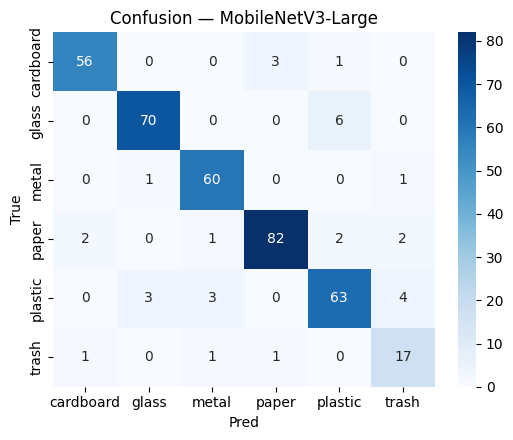

In [ ]:
# MobileNet-V3

run_model("MobileNetV3-Large")


===== EfficientNet-Lite0 =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 18.8MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: tf_efficientnet_lite0
    epoch 01/12  val_f1=0.7420
    epoch 02/12  val_f1=0.8126
    epoch 03/12  val_f1=0.8550
    epoch 04/12  val_f1=0.8675
    epoch 05/12  val_f1=0.8726
    epoch 06/12  val_f1=0.8644
    epoch 07/12  val_f1=0.8993
    epoch 08/12  val_f1=0.9029
    epoch 09/12  val_f1=0.9102
    epoch 10/12  val_f1=0.9069
    epoch 11/12  val_f1=0.9004
    epoch 12/12  val_f1=0.9010
  TEST acc=0.8921 f1=0.8733 auc=0.9905 | 13.77MB 0.745GFLOPs 32.27ms 31.0fps
              precision    recall  f1-score   support

   cardboard       1.00      0.92      0.96        60
       glass       0.92      0.91      0.91        76
       metal       0.86      0.89      0.87        62
       paper       0.90      0.89      0.89        89
     plastic       0.91      0.88      0.90        73
       trash       0.61      0.85      0.71        20

    accuracy                           0.89       380
   macro avg       0.87      0.89      0.87       380
weighted avg       0.90      0

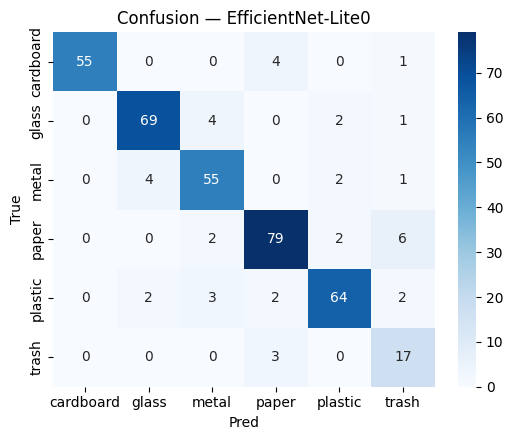

In [ ]:
run_model("EfficientNet-Lite0")


===== ShuffleNetV2 =====
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 109MB/s]

  weights: shufflenet_v2_x1_0


    epoch 01/12  val_f1=0.6141
    epoch 02/12  val_f1=0.7535
    epoch 03/12  val_f1=0.8219
    epoch 04/12  val_f1=0.8646
    epoch 05/12  val_f1=0.8758
    epoch 06/12  val_f1=0.8983
    epoch 07/12  val_f1=0.9035
    epoch 08/12  val_f1=0.9012
    epoch 09/12  val_f1=0.8817
    epoch 10/12  val_f1=0.9059
    epoch 11/12  val_f1=0.9137
    epoch 12/12  val_f1=0.8981
  TEST acc=0.9105 f1=0.8997 auc=0.9900 | 5.2MB 0.303GFLOPs 24.61ms 40.6fps
              precision    recall  f1-score   support

   cardboard       0.95      0.93      0.94        60
       glass       0.87      0.97      0.92        76
       metal       0.90      0.89      0.89        62
       paper       0.93      0.91      0.92        89
     plastic       0.97      0.85      0.91        73
       trash       0.75      0.90      0.82        20

    accuracy                           0.91       380
   macro avg       0.90      0.91      0.90       380
weighted avg       0.91      0.91      0.91       380



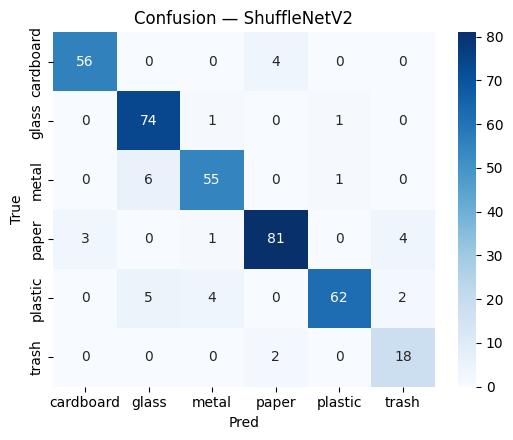

In [ ]:
run_model("ShuffleNetV2")


===== GhostNet =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 20.9MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: ghostnet_100
    epoch 01/12  val_f1=0.7664
    epoch 02/12  val_f1=0.8589
    epoch 03/12  val_f1=0.8757
    epoch 04/12  val_f1=0.8946
    epoch 05/12  val_f1=0.8801
    epoch 06/12  val_f1=0.9085
    epoch 07/12  val_f1=0.8925
    epoch 08/12  val_f1=0.9125
    epoch 09/12  val_f1=0.9255
    epoch 10/12  val_f1=0.9194
    epoch 11/12  val_f1=0.9237
    epoch 12/12  val_f1=0.9271
  TEST acc=0.9289 f1=0.9157 auc=0.9945 | 15.88MB 0.304GFLOPs 36.73ms 27.2fps
              precision    recall  f1-score   support

   cardboard       0.98      0.93      0.96        60
       glass       0.96      0.93      0.95        76
       metal       0.91      0.98      0.95        62
       paper       0.92      0.91      0.92        89
     plastic       0.96      0.90      0.93        73
       trash       0.72      0.90      0.80        20

    accuracy                           0.93       380
   macro avg       0.91      0.93      0.92       380
weighted avg       0.93      0.93      

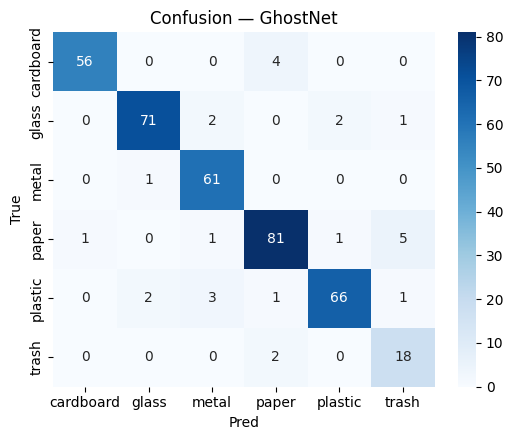

In [ ]:
run_model("GhostNet")


===== SqueezeNet =====
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 81.5MB/s]

  weights: squeezenet1_1


    epoch 01/12  val_f1=0.6143
    epoch 02/12  val_f1=0.7210
    epoch 03/12  val_f1=0.6955
    epoch 04/12  val_f1=0.7222
    epoch 05/12  val_f1=0.7576
    epoch 06/12  val_f1=0.8052
    epoch 07/12  val_f1=0.8212
    epoch 08/12  val_f1=0.8086
    epoch 09/12  val_f1=0.8570
    epoch 10/12  val_f1=0.8633
    epoch 11/12  val_f1=0.8504
    epoch 12/12  val_f1=0.8665
  TEST acc=0.8605 f1=0.8401 auc=0.9845 | 2.92MB 0.546GFLOPs 24.79ms 40.3fps
              precision    recall  f1-score   support

   cardboard       0.96      0.92      0.94        60
       glass       0.85      0.91      0.88        76
       metal       0.86      0.79      0.82        62
       paper       0.90      0.82      0.86        89
     plastic       0.86      0.89      0.87        73
       trash       0.57      0.80      0.67        20

    accuracy                           0.86       380
   macro avg       0.83      0.85      0.84       380
weighted avg       0.87      0.86      0.86       380



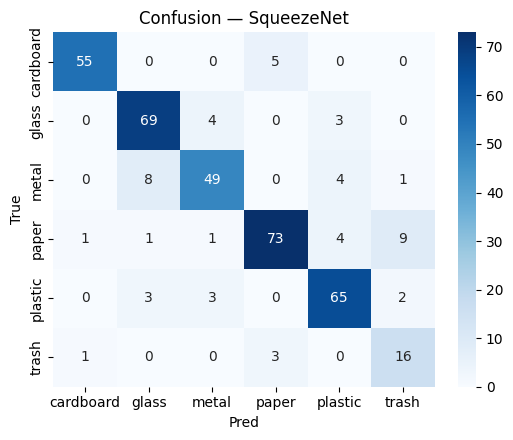

In [ ]:
run_model("SqueezeNet")


===== EfficientViT =====


model.safetensors: reconstructing file:   0%|          |  0.00B / 13.7MB            

model.safetensors: downloading bytes:           |  0.00B            

  weights: efficientvit_b0
    epoch 01/12  val_f1=0.3309
    epoch 02/12  val_f1=0.5609
    epoch 03/12  val_f1=0.5374
    epoch 04/12  val_f1=0.6609
    epoch 05/12  val_f1=0.8337
    epoch 06/12  val_f1=0.9075
    epoch 07/12  val_f1=0.8690
    epoch 08/12  val_f1=0.9266
    epoch 09/12  val_f1=0.8955
    epoch 10/12  val_f1=0.9194
    epoch 11/12  val_f1=0.9286
    epoch 12/12  val_f1=0.9284
  TEST acc=0.9526 f1=0.9476 auc=0.9948 | 8.64MB 0.202GFLOPs 16.3ms 61.3fps
              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        60
       glass       0.96      0.96      0.96        76
       metal       0.91      0.97      0.94        62
       paper       0.97      0.96      0.96        89
     plastic       0.97      0.92      0.94        73
       trash       0.83      1.00      0.91        20

    accuracy                           0.95       380
   macro avg       0.94      0.96      0.95       380
weighted avg       0.95      0.95     

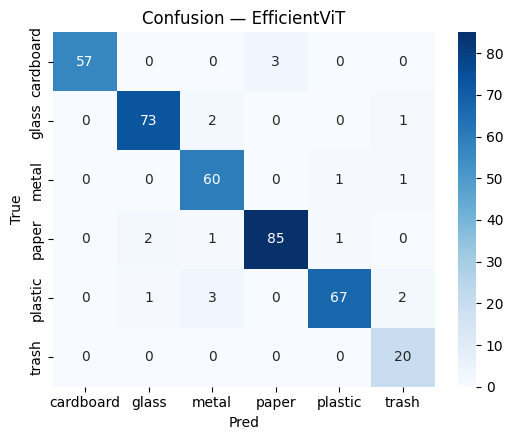

In [ ]:
run_model("EfficientViT")

In [ ]:
# Assemble comparison table (all metrics + efficiency)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc",
               "params_M", "gflops", "size_MB", "cpu_ms", "cpu_ms_p95", "fps", "gpu_mem_MB"]
df = pd.DataFrame({m: {k: RESULTS[m][k] for k in metric_cols} for m in RESULTS}).T
df = df.sort_values("f1", ascending=False)
df.to_csv("/content/model_comparison.csv")

display(df.round(4))

,accuracy,precision,recall,f1,roc_auc,params_M,gflops,size_MB,cpu_ms,cpu_ms_p95,fps,gpu_mem_MB
EfficientViT,0.9526,0.9400,0.9585,0.9476,0.9948,2.137,0.202,8.64,16.30,18.55,61.3,39.1
GhostNet,0.9289,0.9082,0.9276,0.9157,0.9945,3.909,0.304,15.88,36.73,46.86,27.2,56.3
ShuffleNetV2,0.9105,0.8952,0.9089,0.8997,0.9900,1.260,0.303,5.20,24.61,31.88,40.6,30.4
MobileNetV3-Large,0.9158,0.8925,0.9094,0.8997,0.9899,4.210,0.440,17.03,24.92,28.53,40.1,60.3
EfficientNet-Lite0,0.8921,0.8664,0.8877,0.8733,0.9905,3.379,0.745,13.77,32.27,37.43,31.0,59.7
SqueezeNet,0.8605,0.8341,0.8543,0.8401,0.9845,0.726,0.546,2.92,24.79,31.42,40.3,29.7


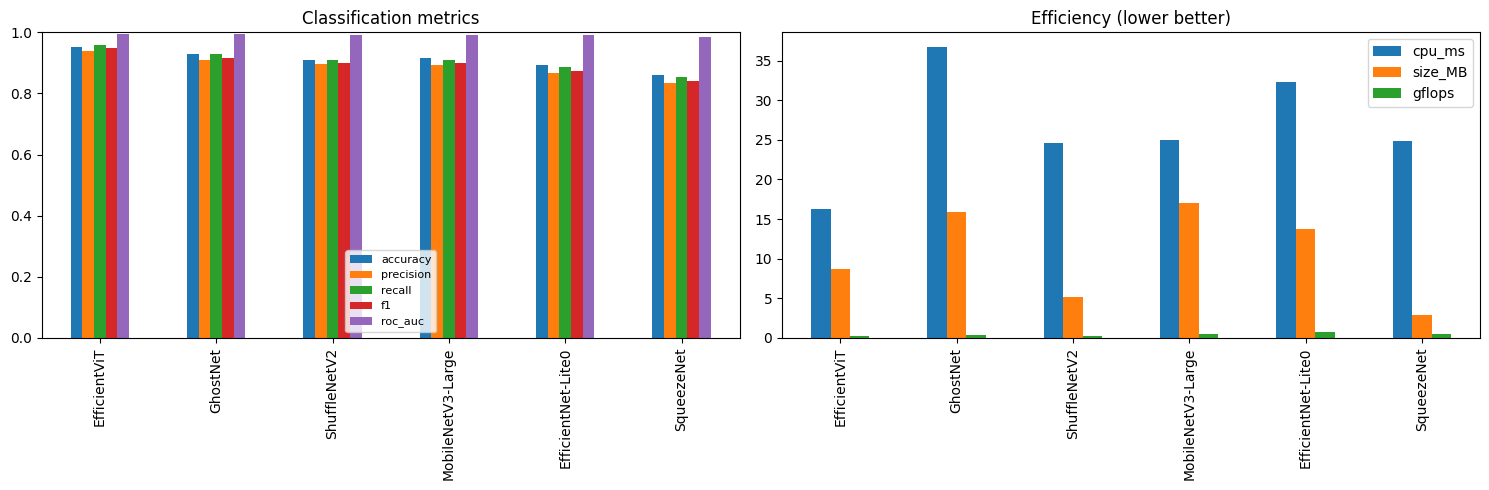

In [ ]:
# Metric bar charts

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot.bar(ax=axes[0])
axes[0].set_title("Classification metrics"); axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)
df[["cpu_ms", "size_MB", "gflops"]].plot.bar(ax=axes[1]); axes[1].set_title("Efficiency (lower better)")
plt.tight_layout(); plt.show()

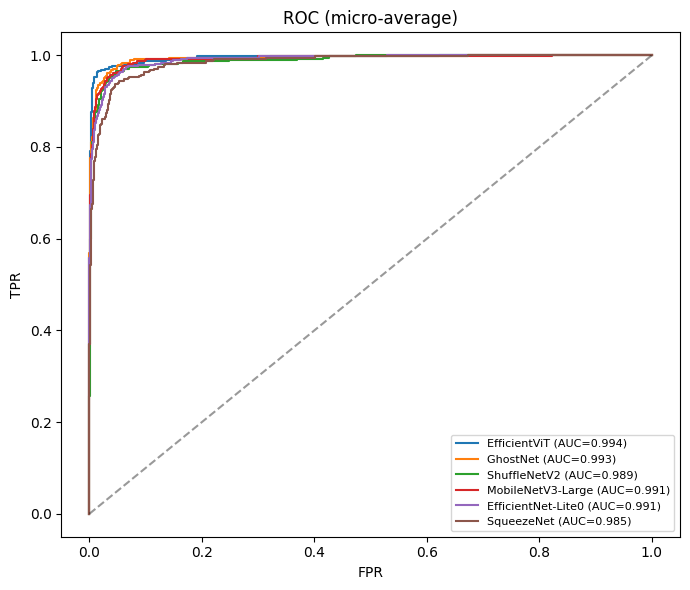

In [ ]:
# ROC curves (micro-average, one per model)

plt.figure(figsize=(7, 6))
yb = label_binarize(TEST_TRUE, classes=list(range(NUM_CLASSES)))
for name in df.index:
    fpr, tpr, _ = roc_curve(yb.ravel(), RESULTS[name]["probs"].ravel())
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC (micro-average)"); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

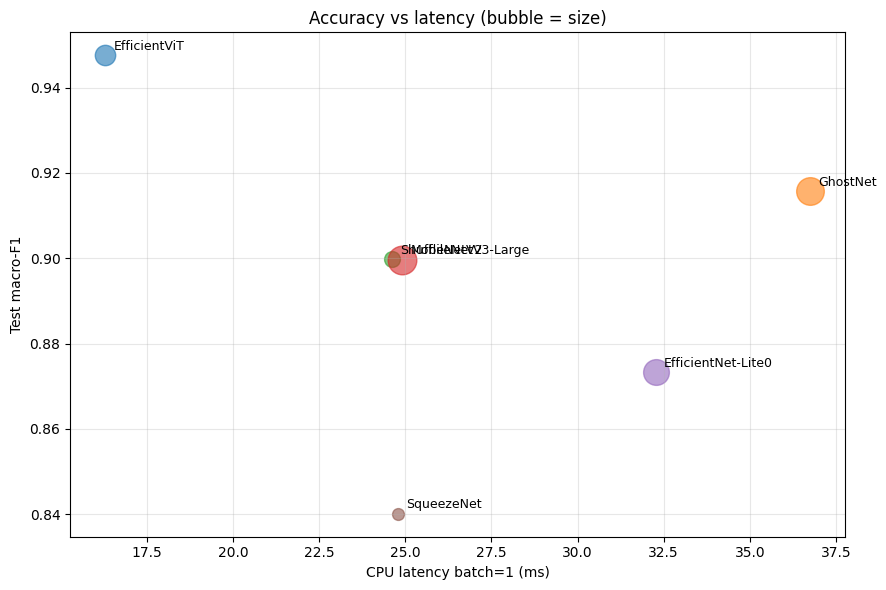

In [ ]:
# Accuracy vs latency trade-off (bubble = size) — the key figure

plt.figure(figsize=(9, 6))
for name in df.index:
    r = df.loc[name]
    plt.scatter(r["cpu_ms"], r["f1"], s=max(r["size_MB"], 1) * 25, alpha=0.6)
    plt.annotate(name, (r["cpu_ms"], r["f1"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
plt.xlabel("CPU latency batch=1 (ms)"); plt.ylabel("Test macro-F1")
plt.title("Accuracy vs latency (bubble = size)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

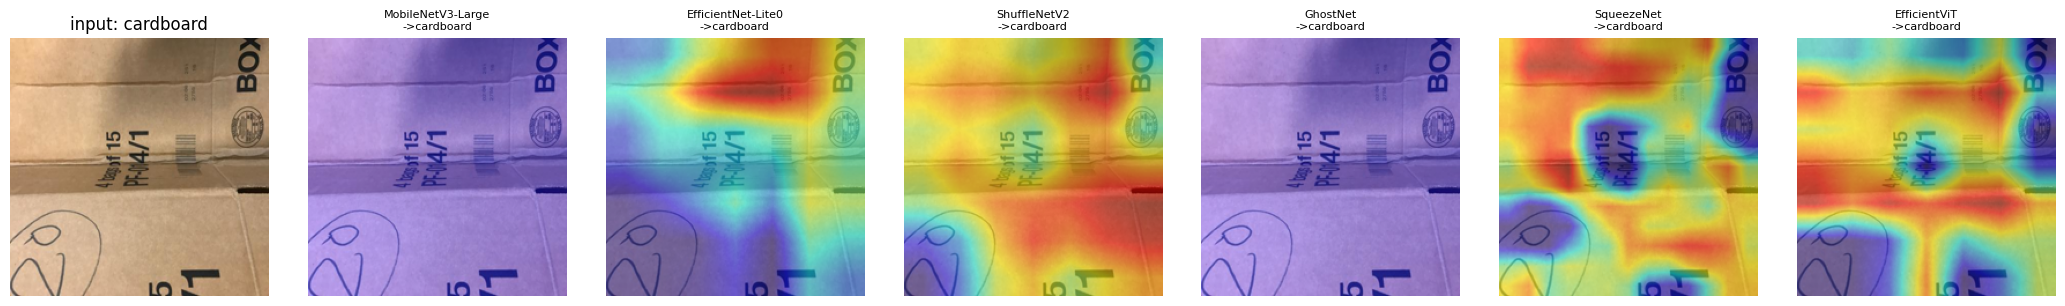

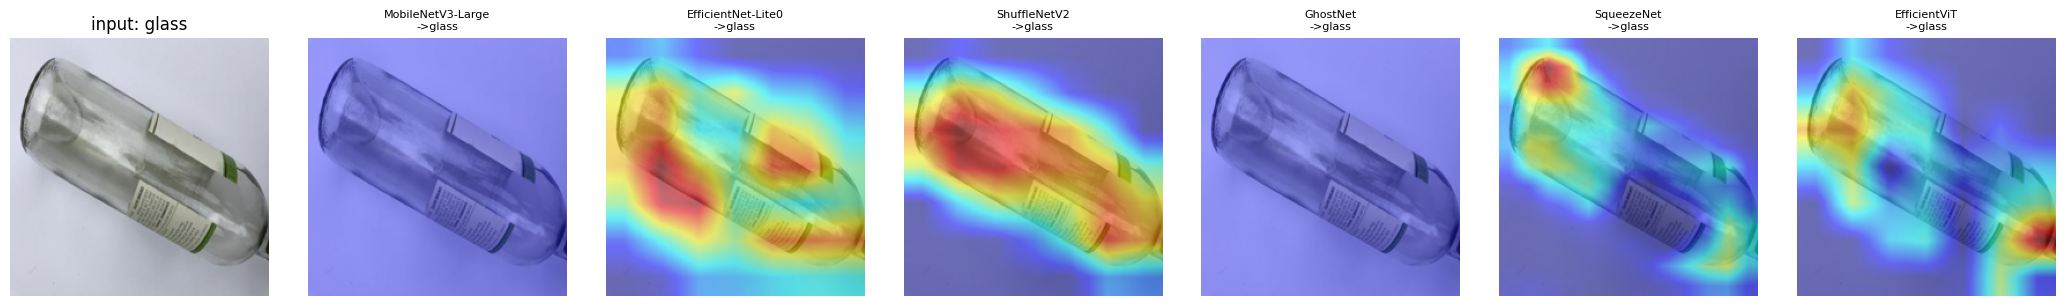

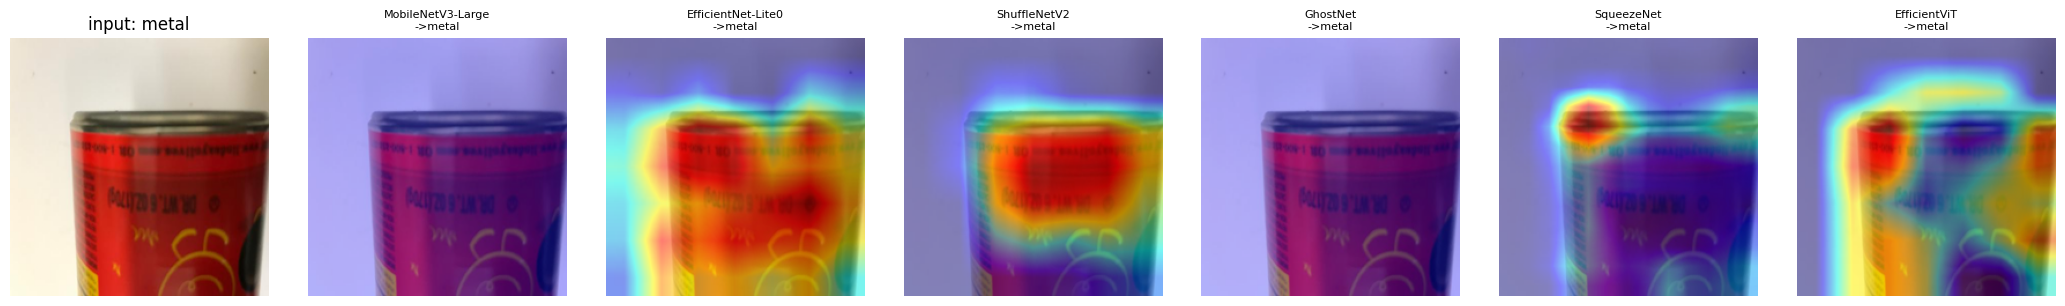

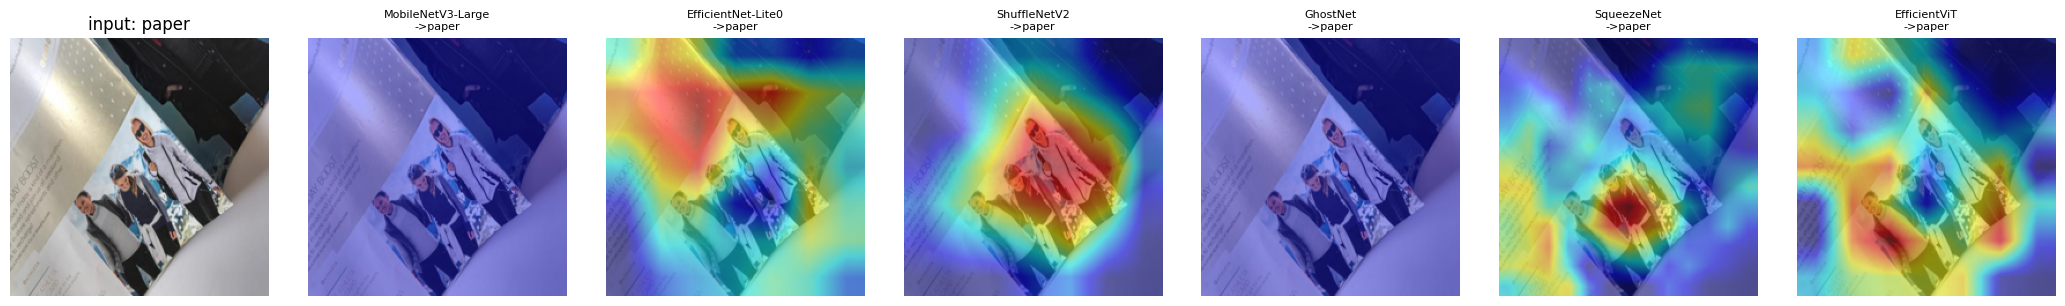

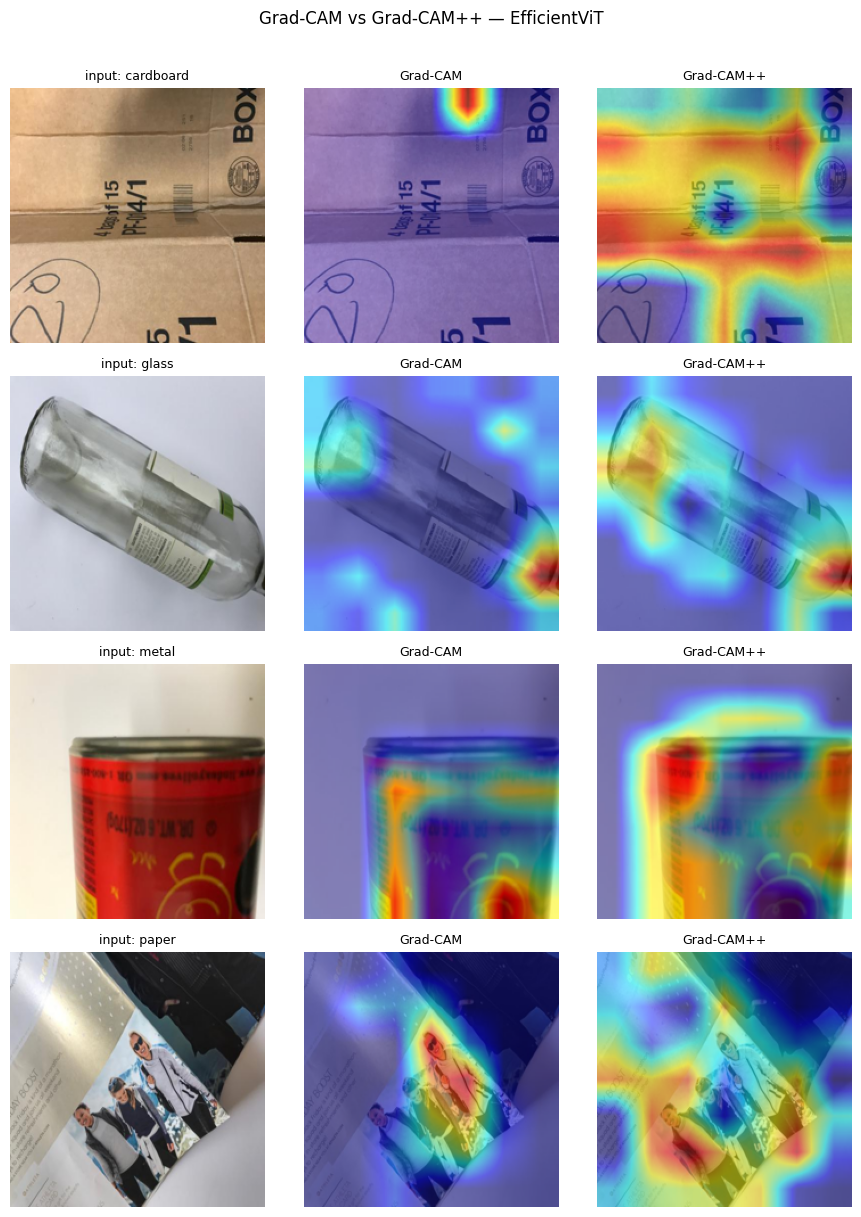

In [ ]:
# Grad-CAM & Grad-CAM++

sample_specs = []
for c in CLASSES[:4]:
    d = os.path.join(SPLIT_ROOT, "test", c)
    f = next(f for f in os.listdir(d) if f.lower().endswith(IMG_EXT))
    sample_specs.append((c, os.path.join(d, f)))

for cls, path in sample_specs:
    rgb, tensor = to_input(path)
    fig, axes = plt.subplots(1, len(RESULTS) + 1, figsize=(3 * (len(RESULTS) + 1), 3))
    axes[0].imshow(rgb); axes[0].set_title(f"input: {cls}"); axes[0].axis("off")
    for ax, name in zip(axes[1:], RESULTS.keys()):
        m = load_trained(name)
        with torch.inference_mode(): pred = int(m(tensor.to(DEVICE)).argmax(1))
        g = GradCAMPlusPlus(model=m, target_layers=[last_conv_layer(m)])(
                input_tensor=tensor.to(DEVICE), targets=[ClassifierOutputTarget(pred)])[0]
        ax.imshow(show_cam_on_image(rgb, g, use_rgb=True))
        ax.set_title(f"{name}\n->{CLASSES[pred]}", fontsize=8); ax.axis("off")
        del m
        if DEVICE == "cuda": torch.cuda.empty_cache()
    plt.tight_layout(); plt.show()

top = df.index[0]; m = load_trained(top)
fig, axes = plt.subplots(len(sample_specs), 3, figsize=(9, 3 * len(sample_specs)))
for row, (cls, path) in enumerate(sample_specs):
    rgb, tensor = to_input(path)
    with torch.inference_mode(): pred = int(m(tensor.to(DEVICE)).argmax(1))
    tgt = [ClassifierOutputTarget(pred)]
    gc   = GradCAM(model=m, target_layers=[last_conv_layer(m)])(input_tensor=tensor.to(DEVICE), targets=tgt)[0]
    gcpp = GradCAMPlusPlus(model=m, target_layers=[last_conv_layer(m)])(input_tensor=tensor.to(DEVICE), targets=tgt)[0]
    for ax, im, t in zip(axes[row], [rgb, show_cam_on_image(rgb, gc, use_rgb=True),
                                     show_cam_on_image(rgb, gcpp, use_rgb=True)],
                         [f"input: {cls}", "Grad-CAM", "Grad-CAM++"]):
        ax.imshow(im); ax.set_title(t, fontsize=9); ax.axis("off")
plt.suptitle(f"Grad-CAM vs Grad-CAM++ — {top}", y=1.01); plt.tight_layout(); plt.show()
del m

In [ ]:
# Composite ranking: accuracy-focused, penalising latency and size (min-max normalised)

from statsmodels.stats.contingency_tables import mcnemar

rank = df.copy()
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
rank["composite"] = (0.55 * norm(rank["f1"]) + 0.15 * norm(rank["roc_auc"])
                     + 0.20 * (1 - norm(rank["cpu_ms"])) + 0.10 * (1 - norm(rank["size_MB"]))).round(4)
rank = rank.sort_values("composite", ascending=False)
display(rank[["f1", "roc_auc", "cpu_ms", "size_MB", "composite"]].round(4))
BEST = rank.index[0]

print("Top by composite:", BEST, "| Top by F1:", df.index[0])

,f1,roc_auc,cpu_ms,size_MB,composite
EfficientViT,0.9476,0.9948,16.30,8.64,0.9595
ShuffleNetV2,0.8997,0.9900,24.61,5.20,0.5874
GhostNet,0.9157,0.9945,36.73,15.88,0.5418
MobileNetV3-Large,0.8997,0.9899,24.92,17.03,0.4997
EfficientNet-Lite0,0.8733,0.9905,32.27,13.77,0.3237
SqueezeNet,0.8401,0.9845,24.79,2.92,0.2169


Top by composite: EfficientViT | Top by F1: EfficientViT


In [ ]:
a, b = df.index[0], df.index[1]
pa = (RESULTS[a]["preds"] == TEST_TRUE); pb = (RESULTS[b]["preds"] == TEST_TRUE)
res = mcnemar([[int(np.sum(pa & pb)), int(np.sum(pa & ~pb))],
               [int(np.sum(~pa & pb)), int(np.sum(~pa & ~pb))]], exact=True)
print(f"McNemar {a} vs {b}: p={res.pvalue:.4f} ->",
      "significant" if res.pvalue < 0.05 else "NOT significant (gap may be noise)")

McNemar EfficientViT vs GhostNet: p=0.0225 -> significant


In [ ]:
# Fine-tune the best model

BEST_NAME = max(RESULTS, key=lambda k: RESULTS[k]["f1"])
print("Fine-tuning:", BEST_NAME)

def get_head(m):
    if hasattr(m, "get_classifier"):
        try: return m.get_classifier()
        except Exception: pass
    if hasattr(m, "fc"): return m.fc
    if hasattr(m, "classifier"): return m.classifier
    raise RuntimeError("head not found")

def run_stage(model, opt, epochs, patience, tag, best_f1, best_state):
    crit = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    wait = 0
    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, val_loader); vf1 = f1_score(yv, pv, average="macro")
        print(f"  [{tag}] epoch {ep+1:02d}/{epochs}  val_f1={vf1:.4f}")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: print(f"  [{tag}] early stop @ {ep+1}"); break
    return best_f1, best_state

set_seed(SEED)
model = load_trained(BEST_NAME); best_f1, best_state = -1, None

for p in model.parameters(): p.requires_grad = False
for p in get_head(model).parameters(): p.requires_grad = True
opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
best_f1, best_state = run_stage(model, opt1, 5, 3, "stage1", best_f1, best_state)

for p in model.parameters(): p.requires_grad = True
head_ids = {id(p) for p in get_head(model).parameters()}
opt2 = torch.optim.AdamW([
    {"params": [p for p in model.parameters() if id(p) not in head_ids], "lr": 2e-5},
    {"params": [p for p in model.parameters() if id(p) in head_ids],     "lr": 4e-4}], weight_decay=1e-4)
best_f1, best_state = run_stage(model, opt2, 25, 6, "stage2", best_f1, best_state)

model.load_state_dict(best_state)
FT_NAME = BEST_NAME + "-FT"
wpath = os.path.join(WEIGHTS_DIR, FT_NAME + ".pt"); torch.save(model.state_dict(), wpath)
metrics, prob, preds = evaluate_full(model, test_loader); eff = measure_efficiency(model)
RESULTS[FT_NAME] = {**metrics, **eff, "used": RESULTS[BEST_NAME]["used"],
                    "weights": wpath, "probs": prob, "preds": preds}
MODEL_REGISTRY[FT_NAME] = MODEL_REGISTRY[BEST_NAME]   # so load_trained works on the FT model
print(f"\n{FT_NAME}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f}")

cmp = pd.DataFrame({"before": {k: RESULTS[BEST_NAME][k] for k in ["accuracy","precision","recall","f1","roc_auc"]},
                    "after":  {k: RESULTS[FT_NAME][k]   for k in ["accuracy","precision","recall","f1","roc_auc"]}})
cmp["delta"] = cmp["after"] - cmp["before"]; display(cmp.round(4))
pc = pd.DataFrame({"before": f1_score(TEST_TRUE, RESULTS[BEST_NAME]["preds"], average=None, labels=range(NUM_CLASSES)),
                   "after":  f1_score(TEST_TRUE, RESULTS[FT_NAME]["preds"],   average=None, labels=range(NUM_CLASSES))},
                  index=CLASSES)
pc["delta"] = pc["after"] - pc["before"]; display(pc.round(3))

Fine-tuning: EfficientViT
  [stage1] epoch 01/5  val_f1=0.9079
  [stage1] epoch 02/5  val_f1=0.9114
  [stage1] epoch 03/5  val_f1=0.9008
  [stage1] epoch 04/5  val_f1=0.9146
  [stage1] epoch 05/5  val_f1=0.9010
  [stage2] epoch 01/25  val_f1=0.9119
  [stage2] epoch 02/25  val_f1=0.9263
  [stage2] epoch 03/25  val_f1=0.9306
  [stage2] epoch 04/25  val_f1=0.9152
  [stage2] epoch 05/25  val_f1=0.9386
  [stage2] epoch 06/25  val_f1=0.9375
  [stage2] epoch 07/25  val_f1=0.9238
  [stage2] epoch 08/25  val_f1=0.9331
  [stage2] epoch 09/25  val_f1=0.9313
  [stage2] epoch 10/25  val_f1=0.9241
  [stage2] epoch 11/25  val_f1=0.9293
  [stage2] early stop @ 11

EfficientViT-FT: acc=0.9553 f1=0.9500


,before,after,delta
accuracy,0.9526,0.9553,0.0026
precision,0.9400,0.9413,0.0013
recall,0.9585,0.9621,0.0036
f1,0.9476,0.9500,0.0024
roc_auc,0.9948,0.9945,-0.0003


,before,after,delta
cardboard,0.974,0.975,0.000
glass,0.961,0.967,0.006
metal,0.938,0.946,0.008
paper,0.960,0.960,-0.000
plastic,0.944,0.944,0.000
trash,0.909,0.909,0.000


CV pool: 2147 | held-out test: 380

===== MobileNetV3-Large =====
  fold 1/5: val_f1=0.8863 test_f1=0.9027
  fold 2/5: val_f1=0.9079 test_f1=0.8818
  fold 3/5: val_f1=0.9262 test_f1=0.9047
  fold 4/5: val_f1=0.9068 test_f1=0.8712
  fold 5/5: val_f1=0.8834 test_f1=0.8826
  -> test_f1 0.8886 +/- 0.0130

===== EfficientNet-Lite0 =====
  fold 1/5: val_f1=0.8745 test_f1=0.8742
  fold 2/5: val_f1=0.8858 test_f1=0.8351
  fold 3/5: val_f1=0.8732 test_f1=0.8937
  fold 4/5: val_f1=0.8645 test_f1=0.8684
  fold 5/5: val_f1=0.8665 test_f1=0.8744
  -> test_f1 0.8692 +/- 0.0191

===== ShuffleNetV2 =====
  fold 1/5: val_f1=0.8840 test_f1=0.8815
  fold 2/5: val_f1=0.9067 test_f1=0.9073
  fold 3/5: val_f1=0.9287 test_f1=0.9036
  fold 4/5: val_f1=0.9079 test_f1=0.8935
  fold 5/5: val_f1=0.8911 test_f1=0.9184
  -> test_f1 0.9009 +/- 0.0126

===== GhostNet =====
  fold 1/5: val_f1=0.9054 test_f1=0.9120
  fold 2/5: val_f1=0.9140 test_f1=0.8890
  fold 3/5: val_f1=0.9315 test_f1=0.9140
  fold 4/5: val_f1=0.93

,val_f1_mean,val_f1_std,test_f1_mean,test_f1_std,test_acc_mean,test_acc_std
EfficientViT,0.9176,0.0178,0.9187,0.0148,0.9258,0.0112
GhostNet,0.9149,0.0183,0.9100,0.0133,0.9237,0.0074
ShuffleNetV2,0.9037,0.0155,0.9009,0.0126,0.9111,0.0113
MobileNetV3-Large,0.9021,0.0157,0.8886,0.0130,0.9005,0.0116
EfficientNet-Lite0,0.8729,0.0075,0.8692,0.0191,0.8832,0.0163
SqueezeNet,0.8415,0.0134,0.8446,0.0164,0.8574,0.0163


  EfficientViT         0.919 +/- 0.015
  GhostNet             0.910 +/- 0.013
  ShuffleNetV2         0.901 +/- 0.013
  MobileNetV3-Large    0.889 +/- 0.013
  EfficientNet-Lite0   0.869 +/- 0.019
  SqueezeNet           0.845 +/- 0.016

EfficientViT vs GhostNet: paired t-test p=0.2821


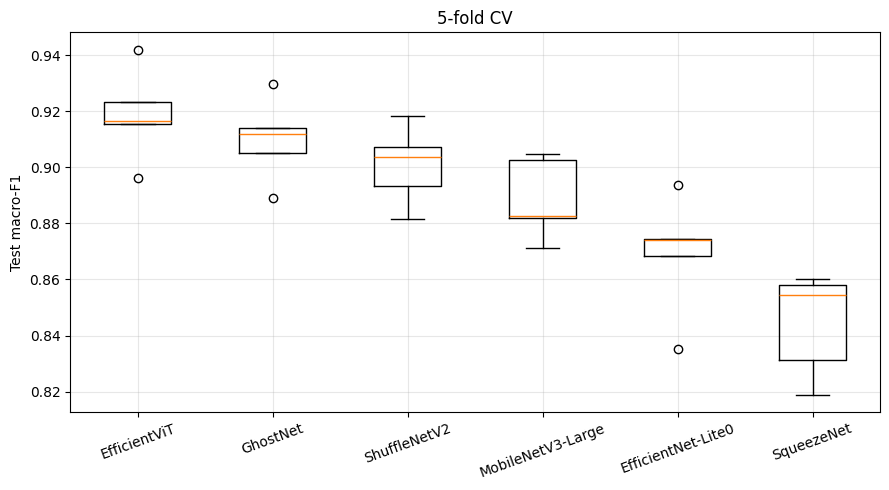

In [ ]:
# K-fold cross-validation

from scipy.stats import ttest_rel, wilcoxon
K, CV_EPOCHS, CV_PATIENCE = 5, 12, 4
MODELS_FOR_CV = list(MODEL_REGISTRY.keys())[:6]   # trim to cut runtime

class PathDataset(Dataset):
    def __init__(self, paths, labels, tf): self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert("RGB")), self.labels[i]

cv_paths, cv_labels = [], []
for split in ["train", "val"]:
    for ci, c in enumerate(CLASSES):
        d = os.path.join(SPLIT_ROOT, split, c)
        for f in os.listdir(d):
            if f.lower().endswith(IMG_EXT): cv_paths.append(os.path.join(d, f)); cv_labels.append(ci)
cv_paths, cv_labels = np.array(cv_paths), np.array(cv_labels)
print(f"CV pool: {len(cv_paths)} | held-out test: {len(TEST_TRUE)}")

def train_on_loaders(model, tr_ld, va_ld, weights, epochs, patience):
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    best_f1, best_state, wait = -1, None, 0
    for ep in range(epochs):
        model.train()
        for x, y in tr_ld:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.autocast(device_type=("cuda" if DEVICE == "cuda" else "cpu"), enabled=(DEVICE == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        yv, pv, _ = _infer(model, va_ld); vf1 = f1_score(yv, pv, average="macro")
        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state); return model, best_f1

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
CV = {}
for name in MODELS_FOR_CV:
    print(f"\n===== {name} =====")
    CV[name] = {"val_f1": [], "test_f1": [], "test_acc": []}
    for fold, (tr_idx, va_idx) in enumerate(skf.split(cv_paths, cv_labels), 1):
        set_seed(SEED + fold)
        tr_ld = DataLoader(PathDataset(cv_paths[tr_idx], cv_labels[tr_idx], train_tf),
                           BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
        va_ld = DataLoader(PathDataset(cv_paths[va_idx], cv_labels[va_idx], eval_tf),
                           BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        c = np.bincount(cv_labels[tr_idx], minlength=NUM_CLASSES).astype(float)
        w = torch.tensor(c.sum() / (NUM_CLASSES * c), dtype=torch.float32)
        m, _ = build_model(MODEL_REGISTRY[name], NUM_CLASSES)
        m, vf1 = train_on_loaders(m, tr_ld, va_ld, w, CV_EPOCHS, CV_PATIENCE)
        mt, _, _ = evaluate_full(m, test_loader)
        CV[name]["val_f1"].append(vf1); CV[name]["test_f1"].append(mt["f1"]); CV[name]["test_acc"].append(mt["accuracy"])
        print(f"  fold {fold}/{K}: val_f1={vf1:.4f} test_f1={mt['f1']:.4f}")
        del m
        if DEVICE == "cuda": torch.cuda.empty_cache()
    print(f"  -> test_f1 {np.mean(CV[name]['test_f1']):.4f} +/- {np.std(CV[name]['test_f1']):.4f}")

cv_df = pd.DataFrame({n: {"val_f1_mean": np.mean(v["val_f1"]), "val_f1_std": np.std(v["val_f1"]),
                          "test_f1_mean": np.mean(v["test_f1"]), "test_f1_std": np.std(v["test_f1"]),
                          "test_acc_mean": np.mean(v["test_acc"]), "test_acc_std": np.std(v["test_acc"])}
                      for n, v in CV.items()}).T.sort_values("test_f1_mean", ascending=False)
display(cv_df.round(4))
for n, r in cv_df.iterrows(): print(f"  {n:20s} {r['test_f1_mean']:.3f} +/- {r['test_f1_std']:.3f}")

a, b = cv_df.index[0], cv_df.index[1]
fa, fb = CV[a]["test_f1"], CV[b]["test_f1"]
print(f"\n{a} vs {b}: paired t-test p={ttest_rel(fa, fb).pvalue:.4f}")
plt.figure(figsize=(9, 5))
plt.boxplot([CV[n]["test_f1"] for n in cv_df.index], labels=list(cv_df.index))
plt.ylabel("Test macro-F1"); plt.title(f"{K}-fold CV"); plt.xticks(rotation=20)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Background remove

from PIL import Image
from rembg import remove
import io

def remove_background(image_path):

    with open(image_path, "rb") as f:
        input_bytes = f.read()

    output_bytes = remove(input_bytes)

    img = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    alpha = img.getchannel("A")
    bbox = alpha.getbbox()

    if bbox:
        img = img.crop(bbox)

    background = Image.new("RGB", img.size, (255,255,255))
    background.paste(img, mask=img.split()[3])

    output_path = "photo_nobg.jpg"
    background.save(output_path)

    return output_path

In [ ]:
from rembg import remove
from PIL import Image
import io

def remove_background(image_path):

    with open(image_path, "rb") as f:
        input_bytes = f.read()

    output_bytes = remove(input_bytes)

    img = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    alpha = img.getchannel("A")
    bbox = alpha.getbbox()

    if bbox:
        img = img.crop(bbox)

    background = Image.new("RGB", img.size, (255,255,255))
    background.paste(img, mask=img.getchannel("A"))

    return background

<IPython.core.display.Javascript object>

Using: EfficientViT-FT
Prediction: plastic (34.6%)
  plastic       34.6%
  metal         28.5%
  glass         13.0%
  cardboard     11.4%
  paper          6.7%
  trash          5.9%


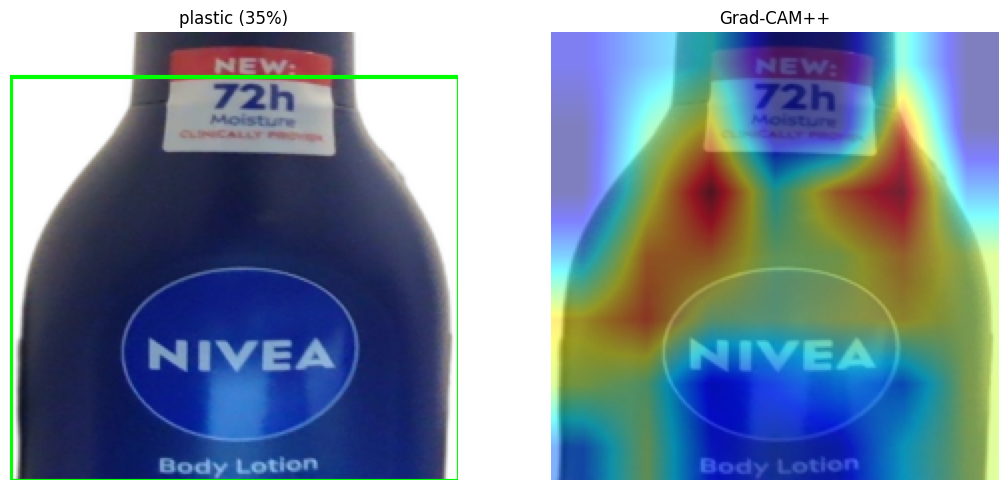

In [ ]:
# Predict image + CAM localization

import cv2
from matplotlib.patches import Rectangle
from google.colab import files
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename="photo.jpg", quality=0.9):
    display(Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Capture'; div.appendChild(capture);
        const video = document.createElement('video'); video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div); div.appendChild(video);
        video.srcObject = stream; await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((r) => capture.onclick = r);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth; canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop()); div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }'''))
    data = eval_js(f"takePhoto({quality})")
    with open(filename, "wb") as f: f.write(b64decode(data.split(",")[1]))
    return filename

capture_img = take_photo("photo.jpg")

PREDICT_WITH = max(RESULTS, key=lambda k: RESULTS[k]["f1"])
model = load_trained(PREDICT_WITH); print("Using:", PREDICT_WITH)

img = remove_background(capture_img)

x = eval_tf(img).unsqueeze(0).to(DEVICE)
with torch.inference_mode(): probs = F.softmax(model(x), 1)[0].cpu().numpy()
pred = int(probs.argmax())
print(f"Prediction: {CLASSES[pred]} ({probs[pred]*100:.1f}%)")
for c, p in sorted(zip(CLASSES, probs), key=lambda t: -t[1]): print(f"  {c:12s} {p*100:5.1f}%")

tensor = eval_tf(img).unsqueeze(0)

rgb = np.array(
    img.resize((224, 224), Image.Resampling.BILINEAR)
).astype(np.float32) / 255.0

heat = GradCAMPlusPlus(model=model, target_layers=[last_conv_layer(model)])(
           input_tensor=tensor.to(DEVICE), targets=[ClassifierOutputTarget(pred)])[0]
mask = (heat >= 0.5 * heat.max()).astype(np.uint8)
cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(rgb); ax[0].axis("off"); ax[0].set_title(f"{CLASSES[pred]} ({probs[pred]*100:.0f}%)")
if cnts:
    x0, y0, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    ax[0].add_patch(Rectangle((x0, y0), w, h, fill=False, edgecolor="lime", linewidth=3))
ax[1].imshow(show_cam_on_image(rgb, heat, use_rgb=True)); ax[1].axis("off"); ax[1].set_title("Grad-CAM++")
plt.tight_layout(); plt.show()